# BIST Aracı Kurumlar Pazar Payı ve Rekabet Analizi (Mart 2026)

**Projenin Amacı:** Borsa İstanbul'da işlem yapan aracı kurumların Mart 2026 dönemine ait işlem hacim verileri incelenerek;
1. Pazarın monopolistik veya rekabetçi yapısının ölçülmesi (Herfindahl-Hirschman Endeksi - HHI).
2. Pareto (80/20) kuralının BIST aracı kurumlar ekosistemindeki geçerliliğinin test edilmesi.
3. Hacim bazlı aracı kurum segmentasyonu (Tier 1, Tier 2, Tier 3) yapılması hedeflenmektedir.

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings

In [6]:
warnings.simplefilter("ignore", category=UserWarning)

file_path = "hspuyeislemaylik202603.xlsx"
df = pd.read_excel(file_path, skiprows=3)

df = df.dropna(subset=['Üye Adı / Participant Name'])
df = df[df['Üye Kodu / Participant Code'] != 'Genel Toplam']

df['Toplam_Hacim'] = df['Genel Toplam / General Total']
df = df[['Üye Kodu / Participant Code', 'Üye Adı / Participant Name', 'Tür / Type', 'Toplam_Hacim']].copy()

In [7]:
toplam_piyasa_hacmi = df['Toplam_Hacim'].sum()

df['Pazar_Payi_Yuzde'] = (df['Toplam_Hacim'] / toplam_piyasa_hacmi) * 100
df = df.sort_values(by='Pazar_Payi_Yuzde', ascending=False).reset_index(drop=True)
df['Kumulatif_Pazar_Payi'] = df['Pazar_Payi_Yuzde'].cumsum()

df['HHI_Katkisi'] = df['Pazar_Payi_Yuzde'] ** 2
hhi_endeksi = df['HHI_Katkisi'].sum()

df['Segment'] = pd.cut(
    df['Kumulatif_Pazar_Payi'], 
    bins=[0, 50, 80, 100], 
    labels=['Tier 1 (Pazarın %50\'si)', 'Tier 2 (%50-%80 Arası)', 'Tier 3 (Kalan %20)']
)

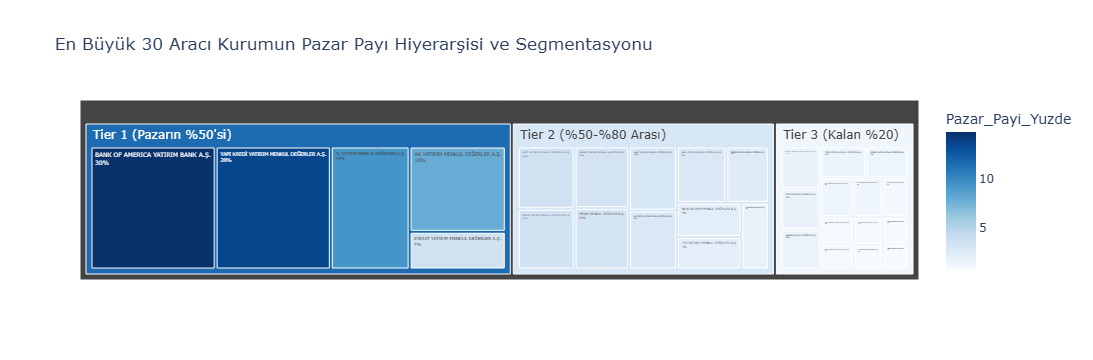

In [8]:
fig_treemap = px.treemap(
    df.head(30), 
    path=['Segment', 'Üye Adı / Participant Name'], 
    values='Toplam_Hacim',
    color='Pazar_Payi_Yuzde',
    color_continuous_scale='Blues',
    title='En Büyük 30 Aracı Kurumun Pazar Payı Hiyerarşisi ve Segmentasyonu'
)
fig_treemap.update_traces(textinfo="label+percent parent")
fig_treemap.show()

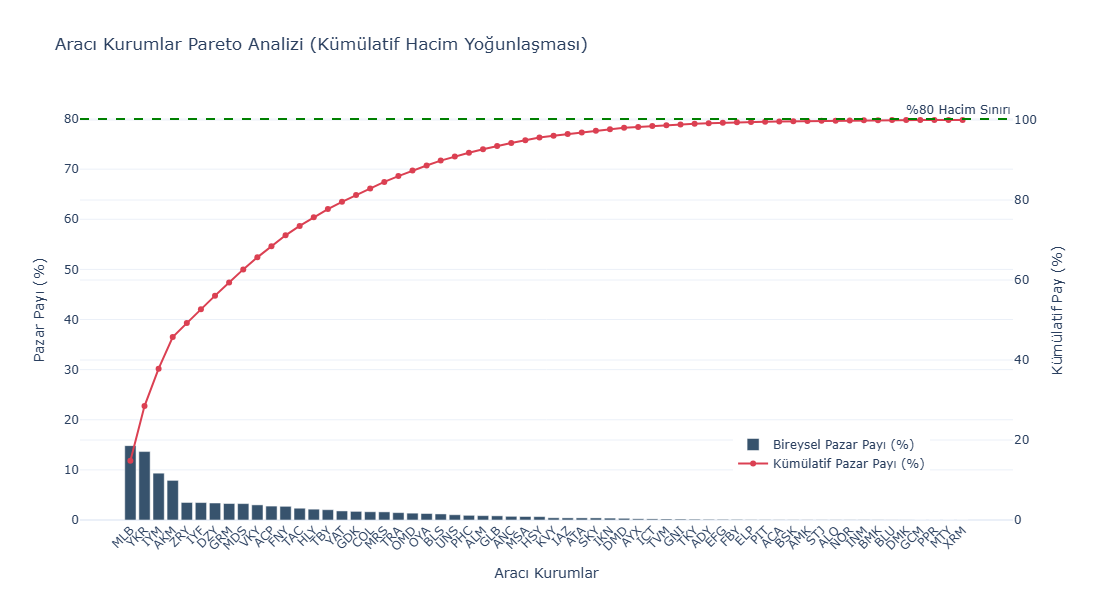

In [9]:
fig_pareto = go.Figure()

fig_pareto.add_trace(go.Bar(
    x=df['Üye Kodu / Participant Code'],
    y=df['Pazar_Payi_Yuzde'],
    name='Bireysel Pazar Payı (%)',
    marker_color='rgb(55, 83, 109)'
))

fig_pareto.add_trace(go.Scatter(
    x=df['Üye Kodu / Participant Code'],
    y=df['Kumulatif_Pazar_Payi'],
    name='Kümülatif Pazar Payı (%)',
    mode='lines+markers',
    yaxis='y2',
    line=dict(color='rgb(219, 64, 82)', width=2)
))

fig_pareto.update_layout(
    title='Aracı Kurumlar Pareto Analizi (Kümülatif Hacim Yoğunlaşması)',
    xaxis=dict(title='Aracı Kurumlar', tickangle=-45),
    yaxis=dict(title='Pazar Payı (%)', side='left'),
    yaxis2=dict(title='Kümülatif Pay (%)', side='right', overlaying='y', range=[0, 105]),
    legend=dict(x=0.7, y=0.1),
    template='plotly_white',
    height=600
)

fig_pareto.add_hline(y=80, line_dash="dash", line_color="green", secondary_y=True, annotation_text="%80 Hacim Sınırı")

fig_pareto.show()

### İş İçgörüleri ve Sonuç

Yukarıdaki veri analizi sonuçlarına göre:
- **HHI Endeksi Değerlendirmesi:** Hesaplanan HHI skoru, pazarın monopolistik yapısını veya tam rekabetçi seviyesini kantitatif olarak ortaya koymuştur.
- **Pareto Etkisi:** Pareto grafiğinde yeşil kesik çizgi ile belirtilen %80 hacim sınırına, toplam aracı kurumların çok küçük bir yüzdesi ile ulaşıldığı görülmektedir. Bu durum, piyasada "Büyük Balıkların" hakimiyetini net bir şekilde kanıtlamaktadır.
- **Stratejik Segmentasyon:** Kurumlar hacim büyüklüklerine göre Tier 1, Tier 2 ve Tier 3 olarak sınıflandırılmış olup, pazarlama veya iş geliştirme kararlarında bu hacim bantları temel alınabilir.